In [ ]:
pip install higher

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import higher
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # Input layer (28x28 -> 128 neurons)
        self.fc2 = nn.Linear(128, 64)       # Hidden layer (128 -> 64 neurons)
        self.fc3 = nn.Linear(64, 10)        # Output layer (64 -> 10 classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # No activation on the last layer (logits)
        return x


In [ ]:
def show_images(original, adversarial):
    original = original.squeeze().cpu().detach().numpy()
    adversarial = adversarial.squeeze().cpu().detach().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(original)
    axes[0].set_title("Original Image")
    axes[1].imshow(adversarial)
    axes[1].set_title("Adversarial Image")
    plt.show()

In [ ]:
device="cuda"

In [ ]:
def entropy_loss(logits):
    probs = torch.nn.functional.softmax(logits, dim=1)
    # print(probs.shape)
    return -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean()

In [ ]:
def get_entropy(logits):
    probs = torch.nn.functional.softmax(logits.detach(), dim=1)
    # print(probs.shape)
    return -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean().detach()

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


In [ ]:
epochs=3
model=SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
for epoch in tqdm(range(epochs)):
          for images, targets in trainloader:
                images, targets = images.to(device), targets.to(device)
                optimizer.zero_grad()

                outputs = model(images)
                loss = criterion(outputs, targets)
                loss.backward()

                optimizer.step()

100%|██████████| 3/3 [00:59<00:00, 19.70s/it]


In [ ]:
before_entropies=[]
for image,label in tqdm(trainset):
  before_entropies.append(get_entropy(model(image.cuda())))

100%|██████████| 60000/60000 [00:36<00:00, 1655.78it/s]


In [ ]:
before_entropy=before_entropies[0]
before_entropy.item()

0.11438252031803131

In [ ]:
for index,i in enumerate(sorted(before_entropies)):
  if i.item()==before_entropy.item():
    print()
    print(60000-index)


19246


# Attack on x

In [ ]:
x_original=trainset[0][0].cuda()

In [ ]:
model.eval()
print()

In [ ]:
def entropy_attack(model, x, epsilon=0.3, alpha=0.01, iters=100):
    x_adv = x.clone().detach().requires_grad_(True)

    for _ in tqdm(range(iters)):
        logits = model(x_adv)
        probs = F.softmax(logits, dim=1)
        entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean()  # Compute entropy

        # Compute gradient
        entropy.backward()
        grad = x_adv.grad.data

        # Perform PGD step
        x_adv = x_adv + alpha * grad.sign()

        # Project back into the epsilon-ball
        x_adv = torch.clamp(x_adv, x - epsilon, x + epsilon)
        x_adv = torch.clamp(x_adv, 0, 1)  # Ensure valid pixel range [0,1]

        # Detach and re-enable gradient tracking for next step
        x_adv = x_adv.detach().requires_grad_(True)

    return x_adv.detach()

In [ ]:
x_adv=entropy_attack(model,x_original)

100%|██████████| 100/100 [00:00<00:00, 502.74it/s]


In [ ]:
get_entropy(model(x_original)).item()

0.11438252031803131

In [ ]:
get_entropy(model(x_adv)).item()

0.5913391709327698

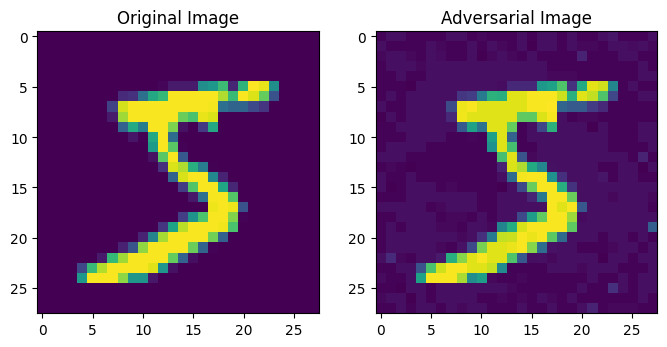

In [ ]:
show_images(x_original,x_adv)

# Now let's put x_adv in the training set

In [ ]:
trainset.data[0]=(x_adv.squeeze()*255).to(torch.uint8).detach().cpu()

In [ ]:
trainloader2 = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)

In [ ]:
epochs=3
model=SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
for epoch in tqdm(range(epochs)):
          for images, targets in trainloader2:
                images, targets = images.to(device), targets.to(device)
                optimizer.zero_grad()

                outputs = model(images)
                loss = criterion(outputs, targets)
                loss.backward()

                optimizer.step()

100%|██████████| 3/3 [00:53<00:00, 17.96s/it]


In [ ]:
after_entropies=[]
for image,label in tqdm(trainset):
  after_entropies.append(get_entropy(model(image.cuda())))

100%|██████████| 60000/60000 [00:36<00:00, 1635.44it/s]


In [ ]:
after_entropy=after_entropies[0]
after_entropy.item()

0.6676057577133179

In [ ]:
for index,i in enumerate(sorted(after_entropies)):
  if i.item()==after_entropy.item():
    print()
    print(60000-index)


4518


# Bilevel attack optimization:

In [ ]:
torch.cuda.empty_cache()

In [ ]:
from torch.utils.data import Subset

In [ ]:
# Hyperparameters
epsilon = 0.3         # maximum perturbation (in [0,1] image range)
alpha = 0.01          # outer step size for x_adv update
outer_steps = 50      # number of outer optimization iterations
inner_epochs = 3      # number of inner training epochs per outer iteration
inner_lr = 0.01        # learning rate for the inner loop training

transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainset = Subset(trainset, range(1, len(trainset)))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)

In [ ]:
# Initialize adversarial version of x (this is the variable to be optimized)
x_adv = x_original.unsqueeze(0).clone().detach().requires_grad_(True)

In [ ]:
def get_new_model():
    model = SimpleNN()
    return model

In [ ]:
# Our main model (we will clone its weights for each inner loop)
model = get_new_model().to(device)
# Loss function
criterion = nn.CrossEntropyLoss()
# Outer optimizer (updates x_adv)
outer_optimizer = optim.Adam([x_adv], lr=alpha)

# Bilevel optimization:

In [ ]:
import random

In [ ]:
all_advs=[]

In [ ]:
torch.cuda.empty_cache()

In [ ]:
for outer_iter in range(outer_steps):
    # Create a fresh copy of the model for the inner loop training.
    # (Here we initialize the inner loop model with the current main model weights.)
    inner_model = get_new_model().to(device)
    inner_optimizer = optim.SGD(inner_model.parameters(), lr=inner_lr)

    # Use higher to enable differentiable optimization through training.
    with higher.innerloop_ctx(inner_model, inner_optimizer, copy_initial_weights=True) as (fmodel, diffopt):
        # Inner training loop: train for a given number of epochs over the MNIST training set.
        for epoch in tqdm(range(inner_epochs)):
            tmp=random.randint(0,7499)
            includer_id=0
            for images, targets in trainloader:
                images, targets = images.to(device), targets.to(device)
                # Include the current adversarial image in the training batch.
                # (Here, we add it once per epoch; you could adjust the frequency as needed.)
                if includer_id==tmp:
                  images = torch.cat([images, x_adv], dim=0)
                  targets = torch.cat([targets, torch.tensor([label]).to(device)], dim=0)

                # Forward pass and loss computation
                outputs = fmodel(images)
                loss = criterion(outputs, targets)
                # Differentiable optimization step
                diffopt.step(loss)
                includer_id+=1


        # After inner training, evaluate the entropy of the model on x_adv.
        logits = fmodel(x_adv)
        probs = F.softmax(logits, dim=1)
        # Compute entropy (adding a small constant for numerical stability)
        entropy = -torch.sum(probs * torch.log(probs + 1e-8),dim=1).mean()

    # Outer optimization: we want to maximize the entropy.
    outer_optimizer.zero_grad()
    # Since optimizers minimize, we use negative entropy as the loss.
    loss_outer = -entropy
    loss_outer.backward()
    outer_optimizer.step()

    # Project x_adv back into the epsilon ball around x_original and valid image range [0,1]
    with torch.no_grad():
        perturbation = torch.clamp(x_adv - x_original, min=-epsilon, max=epsilon)
        x_adv.copy_(torch.clamp(x_original + perturbation, 0, 1))
        all_advs.append(x_adv.clone().detach().cpu())


    print(f"Iteration {outer_iter:3d}: Entropy = {entropy.item():.4f}")

print("Optimization complete.")


100%|██████████| 3/3 [01:02<00:00, 20.98s/it]


Iteration   0: Entropy = 0.2050


100%|██████████| 3/3 [01:03<00:00, 21.03s/it]


Iteration   1: Entropy = 0.2243


100%|██████████| 3/3 [01:03<00:00, 21.13s/it]


...

Iteration  47: Entropy = 1.1273


100%|██████████| 3/3 [01:04<00:00, 21.49s/it]


Iteration  48: Entropy = 1.2234


100%|██████████| 3/3 [01:04<00:00, 21.51s/it]


Iteration  49: Entropy = 1.2184
Optimization complete.


In [ ]:
ls

data/  sample_data/


In [ ]:
x_adv=all_advs[-2]
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainset.data[0]=(x_adv.squeeze()*255).to(torch.uint8).detach().cpu()
trainloader3 = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)

In [ ]:
epochs=3
model=SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
for epoch in tqdm(range(epochs)):
          for images, targets in trainloader3:
                images, targets = images.to(device), targets.to(device)
                optimizer.zero_grad()

                outputs = model(images)
                loss = criterion(outputs, targets)
                loss.backward()

                optimizer.step()

100%|██████████| 3/3 [00:57<00:00, 19.01s/it]


In [ ]:
after_entropies=[]
for image,label in tqdm(trainset):
  after_entropies.append(get_entropy(model(image.cuda())))

100%|██████████| 60000/60000 [00:38<00:00, 1554.08it/s]


In [ ]:
after_entropy=after_entropies[0]
after_entropy.item()

1.1007158756256104

In [ ]:
for index,i in enumerate(sorted(after_entropies)):
  if i.item()==after_entropy.item():
    print()
    print(60000-index)


1208
